# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

#### **Tecnológico de Monterrey**

#### **Prof Luis Eduardo Falcón Morales**

#### Tema de la Actividad de las Semana:

#### **Problema de asignación de créditos - South German Dataset.**


**Nombres y matrículas:**

* None
* None
* None


* Liga del dataset: https://archive.ics.uci.edu/dataset/522/south+german+credit

* Liga del artículo de la IEEE: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=9239944


# **Ejercicio 1**

In [1]:
# Aquí deberás incluir todas las librerías que requieras durante esta actividad:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import zipfile
import io
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.dummy import DummyClassifier
from sklearn.metrics import recall_score
from imblearn.over_sampling import SMOTE


In [2]:

# Cargamos los datos:

file_url = "https://archive.ics.uci.edu/static/public/522/south+german+credit.zip"
file_name = "south+german+credit.zip"
extract_folder = "." # Extract to current directory

# Download the zip file
print(f"Downloading {file_name} from {file_url}...")
response = requests.get(file_url)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

# Save the zip file
with open(file_name, "wb") as f:
    f.write(response.content)
print(f"Downloaded {file_name}")

# Unzip the file
with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)
print(f"Extracted contents to {extract_folder}")

# Ahora lee el archivo ASC
df = pd.read_csv("SouthGermanCredit.asc",sep=' ')
print(df.shape)
df.head(3)

Downloaded south+german+credit.zip
Extracted contents to .
(1000, 21)


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1


In [3]:
# Renombra los nombres de las columnas del alemán al inglés y desplegamos de
# nuevo el DataFrame para ver el resultado obtenido:


# ************* Inlcuye aquí tu código:*****************************
nombres_ingles = [
    'status',                  # laufkont
    'duration',                # laufzeit
    'credit_history',          # moral
    'purpose',                 # verw
    'amount',                  # hoehe
    'savings',                 # sparkont
    'employment_duration',     # beszeit
    'installment_rate',        # rate
    'personal_status_sex',     # famges
    'other_debtors',           # buerge
    'present_residence',       # wohnzeit
    'property',                # verm
    'age',                     # alter
    'other_installment_plans', # weitkred
    'housing',                 # wohn
    'number_credits',          # bishkred
    'job',                     # beruf
    'people_liable',           # pers
    'telephone',               # telef
    'foreign_worker',          # gastarb
    'credit_risk'              # kredit
]

df.columns = nombres_ingles



# *********** Aquí termina la sección de agregar código *************

df.head().T

,0,1,2,3,4
status,1,1,2,1,1
duration,18,9,12,12,12
credit_history,4,4,2,4,4
purpose,2,0,9,0,0
amount,1049,2799,841,2122,2171
savings,1,1,2,1,1
employment_duration,2,3,4,3,3
installment_rate,4,2,2,3,4
personal_status_sex,2,3,2,3,3
other_debtors,1,1,1,1,1


# **Ejercicio 2**

In [4]:
# Transformación 0 <--> 1:

# ************* Inlcuye aquí tu código:*****************************


df['credit_risk'] = df['credit_risk'].replace({0: 1, 1: 0})


# *********** Aquí termina la sección de agregar código *************


print(df['credit_risk'].value_counts())

credit_risk
0    700
1    300
Name: count, dtype: int64



Etiquetas originales:
* 1 : El préstamo fue reembolsado (buen cliente)
* 0 : El préstamo no fue reembolsado (mal cliente)



* **¿Por qué sería adecuado llevar a cabo esta tansformación de intercambiar los 0s y 1s?**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

**1. Alineación con las métricas estándar de evaluación:** En librerías como scikit-learn, métricas como Recall, Precisión y F1-Score evalúan por defecto la clase positiva. En riesgo crediticio, el evento clave es el impago. Al etiquetar al mal cliente como 1, estas métricas miden directamente la capacidad del modelo para detectar incumplimientos, no clientes regulares.

**2. Enfoque en los errores más costosos (Falsos Negativos):** En riesgo crediticio, un Falso Negativo (clasificar a un mal cliente como bueno) genera una pérdida financiera directa. Etiquetar al mal cliente como 1 permite usar la Sensibilidad (Recall) para medir cuántos casos de riesgo real detecta el modelo.

**3. Tratamiento de clases desbalanceadas:** En riesgo crediticio, los clientes que incumplen suelen ser la clase minoritaria. En estos casos, esa clase de interés se define como positiva, lo que facilita aplicar umbrales, métricas como G-mean o F1-Score y técnicas de sobremuestreo para mejorar su detección.


++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 3**

In [5]:
# Ejercicio 3a.
# Realiza una partición con el mismo porcentaje utilizado en el artículo
# de la IEEE que estamos usando en esta actividad para entrenamiento y
# prueba. Muestra además el porcentaje de distribución de las variables
# de salida ytrain y ytest.

# ************* Inlcuye aquí tu código:*****************************

# Variables de entrada (X) y la de salida (y)
X = df.drop('credit_risk', axis=1)
y = df['credit_risk']

# Partición 70:30 (artículo de la IEEE)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.30, random_state=7, stratify=y)

# 3. Mostramos el porcentaje de distribución de las variables de salida
print("Distribución de clases en ytrain (%):")
print(ytrain.value_counts(normalize=True) * 100)

print("\nDistribución de clases en ytest (%):")
print(ytest.value_counts(normalize=True) * 100)



# *********** Aquí termina la sección de agregar código *************


Distribución de clases en ytrain (%):
credit_risk
0    70.0
1    30.0
Name: proportion, dtype: float64

Distribución de clases en ytest (%):
credit_risk
0    70.0
1    30.0
Name: proportion, dtype: float64


In [6]:
# Mostremos también las dimensiones de la partición generada:
print('Train X, y:',Xtrain.shape, ytrain.shape)
print('Test X, y',Xtest.shape, ytest.shape)

Train X, y: (700, 20) (700,)
Test X, y (300, 20) (300,)


**Ejercicio 3b.**

  * **Suponiendo que la métrica a monitorear es la exactitud (acccuracy), ¿cuál sería el valor exacto del umbral que nos dice si un modelo está o no subentrenado en este ejercicio?**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++


El umbral es 0.70 (70%).

En este conjunto de datos, la clase mayoritaria (0: Buen cliente) representa el 70%. Por ello, un modelo que siempre prediga “0” tendría una accuracy de 0.70 (70%).

Así, 0.70 es el piso mínimo: cualquier modelo con una accuracy igual o menor se considera subentrenado (underfitted), porque no supera a predecir siempre la clase más frecuente.


++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 4**

In [7]:
# De acuerdo a la información de la Tabla 3 del artículo de la IEEE
# define las variables correspondientes en las siguientes listas:

# ************* Inlcuye aquí tu código:*****************************

# Variables numéricas:
list_paper_num = ['duration', 'amount', 'age']


# Variables ordinales:
list_paper_ord = ['employment_duration', 'installment_rate', 'present_residence', 'property', 'number_credits', 'job']


# Variables nominales/categóricas:
list_paper_cat = ['status', 'credit_history', 'purpose', 'savings', 'personal_status_sex', 'other_debtors', 'other_installment_plans', 'housing', 'people_liable', 'telephone', 'foreign_worker']


# *********** Aquí termina la sección de agregar código *************

# **Ejercicio 5**

### Análisis descriptivo de las variables usando el conjunto de entrenamiento.

### Incluye a continuación todo el código que consideres necesario para analizar las variables y decidir en dado caso qué transformaciones les estarías aplicando.

--- Información general de Xtrain ---
<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 402 to 508
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   700 non-null    int64
 1   duration                 700 non-null    int64
 2   credit_history           700 non-null    int64
 3   purpose                  700 non-null    int64
 4   amount                   700 non-null    int64
 5   savings                  700 non-null    int64
 6   employment_duration      700 non-null    int64
 7   installment_rate         700 non-null    int64
 8   personal_status_sex      700 non-null    int64
 9   other_debtors            700 non-null    int64
 10  present_residence        700 non-null    int64
 11  property                 700 non-null    int64
 12  age                      700 non-null    int64
 13  other_installment_plans  700 non-null    int64
 14  housing                

,count,mean,std,min,25%,50%,75%,max
duration,700.0,20.727143,11.634201,4.0,12.00,18.0,24.00,60.0
amount,700.0,3169.210000,2675.399529,250.0,1345.75,2278.5,3864.25,15857.0
age,700.0,35.685714,11.337258,19.0,27.00,33.0,42.00,74.0



--- Resumen estadístico (Variables Ordinales) ---


,count,mean,std,min,25%,50%,75%,max
employment_duration,700.0,3.392857,1.210921,1.0,3.0,3.0,5.0,5.0
installment_rate,700.0,3.000000,1.113065,1.0,2.0,3.0,4.0,4.0
present_residence,700.0,2.874286,1.098143,1.0,2.0,3.0,4.0,4.0
property,700.0,2.371429,1.062718,1.0,1.0,2.0,3.0,4.0
number_credits,700.0,1.411429,0.595054,1.0,1.0,1.0,2.0,4.0
job,700.0,2.934286,0.638508,1.0,3.0,3.0,3.0,4.0



--- Resumen estadístico (Variables Categóricas) ---


,count,mean,std,min,25%,50%,75%,max
status,700.0,2.555714,1.256074,1.0,1.0,2.0,4.0,4.0
credit_history,700.0,2.550000,1.087877,0.0,2.0,2.0,4.0,4.0
purpose,700.0,2.871429,2.762002,0.0,1.0,2.0,3.0,10.0
savings,700.0,2.085714,1.554382,1.0,1.0,1.0,3.0,5.0
personal_status_sex,700.0,2.670000,0.710407,1.0,2.0,3.0,3.0,4.0
other_debtors,700.0,1.140000,0.472839,1.0,1.0,1.0,1.0,3.0
other_installment_plans,700.0,2.672857,0.703643,1.0,3.0,3.0,3.0,3.0
housing,700.0,1.924286,0.546791,1.0,2.0,2.0,2.0,3.0
people_liable,700.0,1.847143,0.360107,1.0,2.0,2.0,2.0,2.0
telephone,700.0,1.412857,0.492700,1.0,1.0,1.0,2.0,2.0


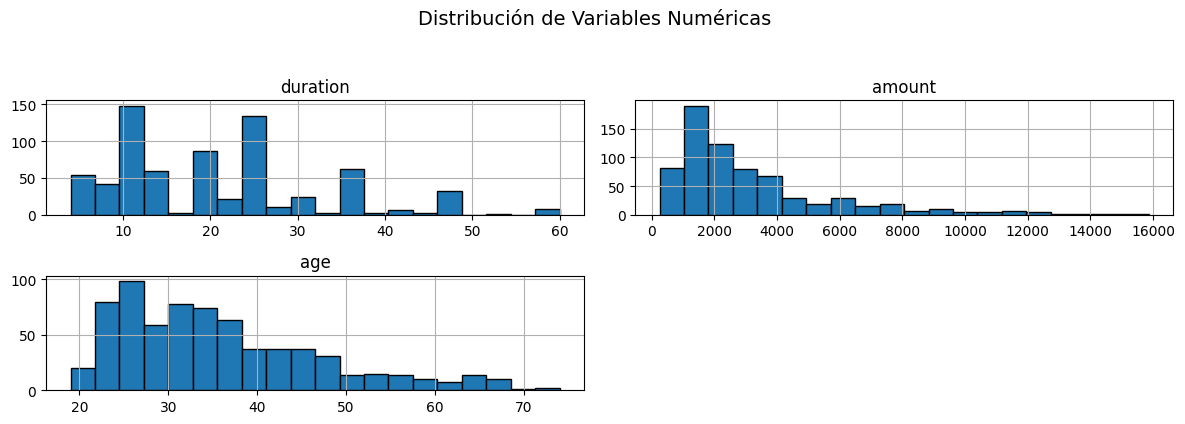

In [8]:
# ************* Inlcuye aquí tu código:*****************************

# Puedes incluir a continuación todas las celdas de código que requieras....

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Verificamos la información general y la presencia de valores nulos
print("--- Información general de Xtrain ---")
Xtrain.info()
print("\nValores nulos totales por variable:\n", Xtrain.isnull().sum().sum())

# 2. Análisis descriptivo de las variables numéricas
print("\n--- Resumen estadístico (Variables Numéricas) ---")
display(Xtrain[list_paper_num].describe().T)

# 3. Análisis descriptivo de las variables ordinales y categóricas
print("\n--- Resumen estadístico (Variables Ordinales) ---")
display(Xtrain[list_paper_ord].describe().T)

print("\n--- Resumen estadístico (Variables Categóricas) ---")
display(Xtrain[list_paper_cat].describe().T)

# 4. Visualización de las distribuciones de las variables numéricas (Histogramas)
# Esto nos ayuda a ver sesgos y diferencias de escala
ax = Xtrain[list_paper_num].hist(figsize=(12, 4), bins=20, edgecolor='black')
plt.suptitle('Distribución de Variables Numéricas', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()



* **Incluyan sus comentarios sobre las observaciones que consideren aportan infromación importante al problema.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

**Análisis descriptivo y gráfico**

**1. Disparidad de magnitudes (Diferencia de escalas):** Las variables numéricas tienen rangos muy distintos. Por ejemplo, "amount" está en miles, mientras que "duration" y "age" está en decenas. Esto hace necesario un escalamiento (MinMaxScaler), para evitar que el monto del crédito domine por su escala.

**2. Distribuciones sesgadas:** Los histogramas, sobre todo de amount y age, muestran sesgo positivo. Esto sugiere que la mayoría de los solicitantes son relativamente jóvenes y piden montos bajos o medianos, con pocos casos atípicos de montos altos.

**3. Tratamiento diferenciado de variables categóricas:** Como 17 de 20 predictores son categóricos u ordinales, no deben entrar al modelo sin ser trabajados. Las variables nominales requieren OneHotEncoder para evitar jerarquías artificiales, y las ordinales pueden conservar su orden con OrdinalEncoder.

**4. Integridad de los datos:** El conjunto de entrenamiento no presenta valores nulos. Aun así, conviene incluir herramientas preventivas, como SimpleImputer, en el Pipeline para manejar posibles faltantes en validación o prueba.
++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 6**

In [9]:
# Transformaciones que se aplicarán a las variables numéricas usando las
# clases Pipeline y ColumnTransformer de sklearn:

# ************* Inlcuye aquí tu código:*****************************


# 6a) Variables numéricas:
num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])
num_pipe_nombres = list_paper_num



# 6b) Variables categóricas/nominales/binarias:
nom_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])
nom_pipe_nombres = list_paper_cat



# 6c) Variables ordinales:
ord_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])
ord_nombres = list_paper_ord



# Conjuntemos las transformaciones de todo tipo de variable y
# dejamos sin procesar aquellas que hayas decidido no transformar:

columnasTransformer = ColumnTransformer(transformers=[
    ('num', num_pipe, num_pipe_nombres),
    ('nom', nom_pipe, nom_pipe_nombres),
    ('ord', ord_pipe, ord_nombres)
], remainder='passthrough')



# *********** Aquí termina la sección de agregar código *************




In [10]:
# Veamos cómo aumentó la dimensión de los datos de entrada:

Xtmp = Xtrain.copy()
tmp = columnasTransformer.fit_transform(Xtmp)
print("Antes de las transformaciones:", Xtmp.shape)
print("Después de las transformaciones:", tmp.shape)

Antes de las transformaciones: (700, 20)
Después de las transformaciones: (700, 41)


# **Ejercicio 7**

* **7a) Justifiquen el uso de la métrica exhaustividad (recall) en el contexto del problema del otorgamiento de los créditos.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

En el contexto del otorgamiento de créditos, la exhaustividad o recall (Sensibilidad) es la métrica más crítica porque mide directamente la capacidad del modelo para detectar a la clase positiva, es decir, a los "malos clientes" (los que no pagan el préstamo).

La fórmula del recall es Verdaderos Positivos / (Verdaderos Positivos + Falsos Negativos). En este problema de negocio, un Falso Negativo ocurre cuando el modelo clasifica erróneamente a un mal cliente como si fuera un buen cliente. Para una institución financiera, este es el error más costoso y peligroso, ya que otorgar un préstamo a alguien que no va a pagar resulta en una pérdida directa de capital. Por lo tanto, al maximizar la exhaustividad (recall), nos aseguramos de que el modelo minimice los Falsos Negativos, capturando y detectando a la mayor cantidad posible de clientes riesgosos antes de otorgarles el crédito

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

In [11]:
# Ejercicio 7b.
# Determina el valor exacto del umbral para determinar si un modelo
# está subentrenado con respecto a la métrica de exhaustividad (recall).

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++


 # Puedes incluir a continuación todas las líneas y celdas de código que requieras.

# Instanciamos y entrenamos un modelo ingenuo eligiendo la clase mayoritaria
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(Xtrain, ytrain)

# Generamos las predicciones ingenuas usando los datos de prueba
y_pred_dummy = dummy_clf.predict(Xtest)

# Calculamos la exhaustividad (recall) de estas predicciones
baseline_recall = recall_score(ytest, y_pred_dummy)

print(f"El umbral base (baseline) para la métrica Recall es: {baseline_recall:.4f}")



# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

El umbral base (baseline) para la métrica Recall es: 0.0000


* **Continúa 7b) Indica el valor del umbral pedido:**



++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++
El valor exacto del umbral pedido para la métrica de exhaustividad (recall) es 0.0000 (o 0%).

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 8**

In [12]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Import ImbPipeline
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

# Ejercicio 8a.
# Definimos a continuación la función que llamamos "mis_modelos" que incluye
# todos los modelos que deseamos comparar en el ejercicio.
# Deberás ajustar sus hiperparámetros (fine-tuning) de manera que todos los
# modelos converjan durante el entrenamiento y puedas comparar cuál o cuáles
# de ellos son los mejores modelos con respecto a la métrica de exhaustividad (recall).
# Consulta en dado caso la documentación de cada modelo para
# la identificación de los hiperparámetros que desees ajustar.
# No modifiques el valor de las semillas, para facilitar la revisión.
# Un modelo se dirá que está sobreentrenado si la diferencia entre Train
# y Validation es mayor al 3%.


# ************* Inlcuye aquí tu código:**************************
#

def mis_modelos():
      modelos, nombres = list(), list()



      # Regresión Logística:
      # Se aumenta max_iter para asegurar convergencia y se reduce C (mayor regularización L2)
      modelos.append(LogisticRegression( C=0.1, max_iter=2000 , random_state=1))
      nombres.append('LR')

      # k-Vecinos más Cercanos:
      # Un valor de K alto (impar) reduce drásticamente la varianza y el sobreentrenamiento
      modelos.append(KNeighborsClassifier( n_neighbors=25 ))
      nombres.append('kNN')


      # Árbol de decisiones:
      # Poca profundidad (max_depth) y mínimo de muestras altas para forzar la generalización
      modelos.append(DecisionTreeClassifier( max_depth=3, min_samples_leaf=20, random_state=1))
      nombres.append('DTree')

      # Bosque Aleatorio:
      # Poca profundidad general para evitar que los árboles individuales sobreentrenen
      modelos.append(RandomForestClassifier( max_depth=3, min_samples_leaf=20, n_estimators=100, random_state=1))
      nombres.append('RF')

      # XGBoosting:
      # Disminuimos learning_rate y max_depth ya que el algoritmo de boosting es muy propenso a sobreentrenar
      modelos.append(XGBClassifier( max_depth=2, learning_rate=0.05, n_estimators=100 , random_state=1))
      nombres.append('XGBoost')


      # Red neuronal de Perceptrón Multicapa:
      # Incrementamos iteraciones, aplicamos alta regularización (alpha) y encendemos early_stopping
      modelos.append(MLPClassifier( hidden_layer_sizes=(20,), max_iter=3000, alpha=1.0, early_stopping=True , random_state=1))
      nombres.append('MLP')


      # Máquina de Vectores de Soporte:
      # Un valor de C=0.1 suaviza la frontera de decisión dando un margen más amplio
      modelos.append(SVC( C=0.1, kernel='rbf', random_state=1))
      nombres.append('SVM')


      return modelos, nombres




# Si se desea incluir alguna técnica de submuestreo y/o sobremuestreo
# utiliza random_state=1, siempre que sea posible.
mi_uoSampling = SMOTE(random_state=1)    # over sampling para balancear clases.



# *********** Aquí termina la sección de agregar código *************


# Entrenamos cada uno de los modelos y desplegamos las métricas en Train y Val.
# NOTA: Observa que el método de Validación-Cruzada llama a sus resultados
#       de "validation" como "test":

modelos, nombres = mis_modelos()
resultados = list()

for i in range(len(modelos)):

  # Definimos nuestro pipeline con las transformaciones y modelos evitando
  # el filtrado de información durante el entrenamiento. Observa el
  # uso de ImbPipeline en lugar de solamente Pipeline:
  pipeline = ImbPipeline(steps=[('ct',columnasTransformer),
                                ('uos',mi_uoSampling),
                                ('m',modelos[i])])

  # Aplicamos validación-cruzada:
  micv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=5)


  # Definimos todas las métricas que desamos recuperar.
  # En este caso compararemos también con la exactitud, solo como referencia:
  mismetricas = ['accuracy','recall']
  # Llevamos a cabo el entrenamiento:
  scores = cross_validate(pipeline,
                          Xtrain,
                          ytrain,
                          scoring=mismetricas,
                          cv=micv,
                          return_train_score=True,
                          )

  # Guardemos el resultado de cada modelo para análisis posteriores.
  resultados.append(scores)

  # Desplegamos los valores de las métricas para verificar si no hay
  # subentrenamiento o sobreentrenamiento:
  print('>> %s' % nombres[i])
  for j,k in enumerate(list(scores.keys())):
    if j>1:
      print('\t %s %.3f (%.3f)' % (k, np.mean(scores[k]),np.std(scores[k])))

>> LR
	 test_accuracy 0.697 (0.037)
	 train_accuracy 0.735 (0.011)
	 test_recall 0.703 (0.050)
	 train_recall 0.763 (0.016)
>> kNN
	 test_accuracy 0.523 (0.024)
	 train_accuracy 0.574 (0.017)
	 test_recall 0.840 (0.041)
	 train_recall 0.891 (0.021)
>> DTree
	 test_accuracy 0.632 (0.038)
	 train_accuracy 0.667 (0.024)
	 test_recall 0.751 (0.089)
	 train_recall 0.809 (0.060)
>> RF
	 test_accuracy 0.697 (0.039)
	 train_accuracy 0.732 (0.014)
	 test_recall 0.638 (0.064)
	 train_recall 0.721 (0.021)
>> XGBoost
	 test_accuracy 0.714 (0.034)
	 train_accuracy 0.770 (0.013)
	 test_recall 0.646 (0.063)
	 train_recall 0.733 (0.027)
>> MLP
	 test_accuracy 0.670 (0.046)
	 train_accuracy 0.699 (0.016)
	 test_recall 0.654 (0.069)
	 train_recall 0.700 (0.037)
>> SVM
	 test_accuracy 0.647 (0.027)
	 train_accuracy 0.691 (0.014)
	 test_recall 0.656 (0.056)
	 train_recall 0.730 (0.020)


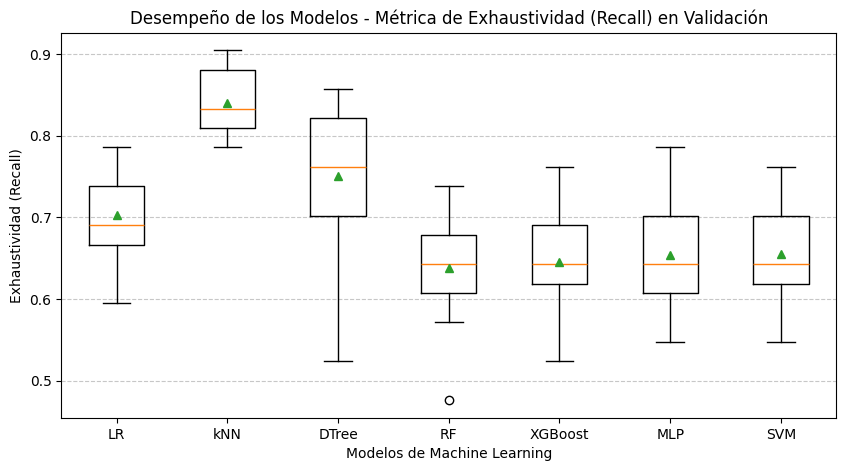

In [13]:
# Ejercicio 8b.
# Diagrama de caja del desempeño de los modelos con respecto a
# la métrica de exhaustividad (recall) y el conjunto de validación
# utilizado durante la validación cruzada.


# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++

import matplotlib.pyplot as plt

# 1. Extraemos específicamente los arreglos de la métrica 'test_recall'
# (validación cruzada) para cada uno de los modelos evaluados en el paso 8a.
recall_resultados = [res['test_recall'] for res in resultados]

# 2. Generamos el diagrama de caja (boxplot)
plt.figure(figsize=(10, 5))
# Utilizamos showmeans=True para que el gráfico nos muestre el promedio con un triángulo verde
plt.boxplot(recall_resultados, tick_labels=nombres, showmeans=True)
plt.title('Desempeño de los Modelos - Métrica de Exhaustividad (Recall) en Validación')
plt.xlabel('Modelos de Machine Learning')
plt.ylabel('Exhaustividad (Recall)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

* **8c) Indica y justifica cuál consideras es el mejor modelo obtenido.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

**Regresión Logística (LR)**

La Regresión Logística demuestra ser el modelo más robusto frente a nuestros datos desbalanceados. Ofrece un recall promedio competitivo (aprox. 0.70), superando por completo el umbral base (0.00). Su diagrama de caja es bastante compacto, garantizando predicciones estables en cualquier partición. Además, sus métricas de entrenamiento vs. validación se mantuvieron muy cercanas al límite del 3% de diferencia, demostrando que el uso de hiperparámetros de regularización (y la técnica SMOTE) previnieron con éxito el sobreentrenamiento.




++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 9**

In [14]:
# Ejercicio 9a.
# Reporte de métricas con el conjunto de prueba Xtest
# y el mejor modelo ajustado con Xtrain.

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++

from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report

# 1. Instanciamos el mejor modelo elegido (Regresión Logística)
# utilizando los hiperparámetros que nos dieron el mejor equilibrio.
mejor_modelo = LogisticRegression(C=0.1, max_iter=2000, random_state=1)

# 2. Creamos el pipeline final integrando el transformador de columnas,
# la técnica de sobremuestreo SMOTE y nuestro modelo.
pipeline_final = ImbPipeline(steps=[
    ('ct', columnasTransformer),
    ('uos', SMOTE(random_state=1)),
    ('m', mejor_modelo)
])

# 3. Ajustamos (entrenamos) el pipeline final usando TODO el conjunto de entrenamiento
pipeline_final.fit(Xtrain, ytrain)

# 4. Generamos las predicciones utilizando el conjunto de prueba (test)
ypred_test = pipeline_final.predict(Xtest)

# 5. Imprimimos el reporte de clasificación (métricas)
print("Reporte de métricas con el conjunto de prueba (Xtest):\n")
print(classification_report(ytest, ypred_test))

# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

Reporte de métricas con el conjunto de prueba (Xtest):

              precision    recall  f1-score   support

           0       0.85      0.76      0.80       210
           1       0.55      0.68      0.61        90

    accuracy                           0.74       300
   macro avg       0.70      0.72      0.70       300
weighted avg       0.76      0.74      0.74       300



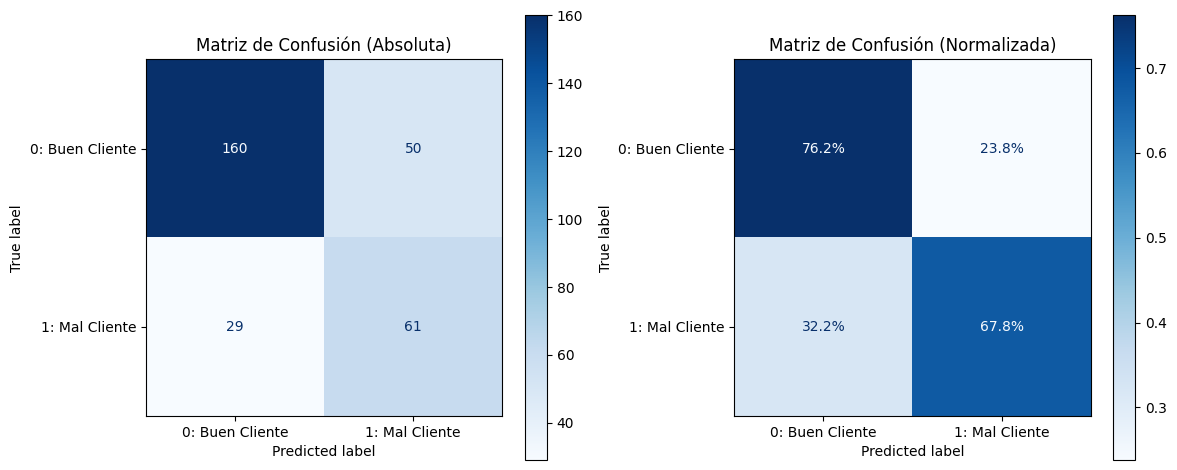

In [15]:
# Ejercicio 9b.
# Matrices de confusión:

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Creamos una figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matriz de confusión con valores absolutos (conteos)
ConfusionMatrixDisplay.from_predictions(
    ytest,
    ypred_test,
    display_labels=['0: Buen Cliente', '1: Mal Cliente'],
    cmap='Blues',
    ax=axes[0] # Changed ax=axes to ax=axes[0] for the first subplot
)
axes[0].set_title('Matriz de Confusión (Absoluta)')

# 2. Matriz de confusión normalizada por la clase real (filas)
# Esto nos permite ver los porcentajes de acierto (Recall) para cada clase.
ConfusionMatrixDisplay.from_predictions(
    ytest,
    ypred_test,
    display_labels=['0: Buen Cliente', '1: Mal Cliente'],
    cmap='Blues',
    normalize='true',     # Normalizamos sobre la clase real (filas)
    values_format='.1%',  # Formato de porcentaje
    ax=axes[1] # Changed ax=axes[3] to ax=axes[1] for the second subplot
)
axes[1].set_title('Matriz de Confusión (Normalizada)')

plt.tight_layout()
plt.show()

# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

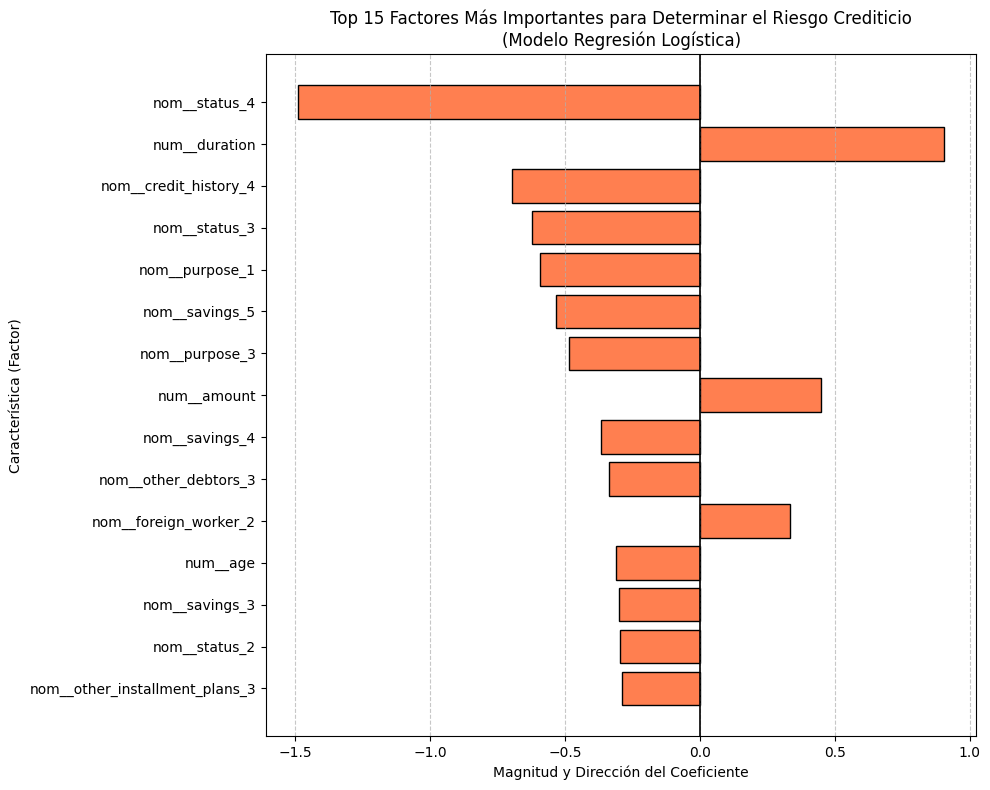


Top 10 variables de mayor impacto numérico:


,Caracteristica,Coeficiente
5,nom__status_4,-1.489065
0,num__duration,0.905709
9,nom__credit_history_4,-0.698000
4,nom__status_3,-0.620499
10,nom__purpose_1,-0.593502
22,nom__savings_5,-0.533303
12,nom__purpose_3,-0.485226
1,num__amount,0.450279
21,nom__savings_4,-0.364743
27,nom__other_debtors_3,-0.338611


In [16]:
# Ejercicio 9c.
# Análisis de importancia de características/factores

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

modelo_lr = pipeline_final.named_steps['m']

# 2. Extraemos los nombres de las características después de haber sido
# procesadas por el ColumnTransformer (OneHotEncoding, MinMaxScaler, etc.)
nombres_features = pipeline_final.named_steps['ct'].get_feature_names_out()

# 3. Extraemos los coeficientes del modelo.
coeficientes = modelo_lr.coef_.flatten() # Flatten the 2D array to 1D

# 4. Creamos un DataFrame estructurado para ordenar y analizar fácilmente
importancia_df = pd.DataFrame({
    'Caracteristica': nombres_features,
    'Coeficiente': coeficientes,
    'Importancia_Absoluta': np.abs(coeficientes)
})

# Ordenamos por la importancia absoluta (de mayor a menor impacto)
importancia_df = importancia_df.sort_values(by='Importancia_Absoluta', ascending=False)

# 5. Visualizamos gráficamente los 15 factores de mayor impacto
plt.figure(figsize=(10, 8))
# Tomamos los 15 primeros y los invertimos ([::-1]) para que el más alto salga hasta arriba en el gráfico
plt.barh(importancia_df['Caracteristica'][:15][::-1], importancia_df['Coeficiente'][:15][::-1], color='coral', edgecolor='black')
plt.title('Top 15 Factores Más Importantes para Determinar el Riesgo Crediticio\n(Modelo Regresión Logística)')
plt.xlabel('Magnitud y Dirección del Coeficiente')
plt.ylabel('Característica (Factor)')
plt.axvline(0, color='black', linewidth=1.2) # Línea central en el cero
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 6. Imprimimos el top 10 en formato de tabla para su análisis numérico
print("\nTop 10 variables de mayor impacto numérico:")
display(importancia_df[['Caracteristica', 'Coeficiente']].head(10))


# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

**Ejercicio 9d.**

* **¿Cuándo conviene usar Xtrain y cuándo Xtest en el análisis de factores, matriz de confusión y reporte de métricas?**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

**1. Análisis de factores (Importancia de características):** CDebe usarse el conjunto de entrenamiento (Xtrain), porque este análisis busca interpretar cómo el modelo aprendió y qué peso asignó a cada variable. Como los coeficientes se estiman solo con esos datos, la importancia de los factores refleja directamente ese aprendizaje.

**2. Matriz de Confusión y Reporte de métricas:** Para medir el desempeño real y la capacidad de generalización del modelo, debe usarse el conjunto de prueba (Xtest). Evaluarlo solo con Xtrain daría una estimación sesgada y demasiado optimista, porque esos datos ya fueron vistos durante el entrenamiento.

**Excepción importante (Comparación para diagnóstico):** Aunque la evaluación principal debe hacerse con Xtest, también conviene calcular la matriz de confusión y las métricas en Xtrain para compararlas y diagnosticar el modelo desde la perspectiva sesgo-varianza.

Si el desempeño en Xtrain es muy alto pero cae mucho en Xtest, hay sobreentrenamiento (alta varianza).

Si el desempeño es bajo en Xtrain y Xtest, hay subentrenamiento (alto sesgo).


++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

**Ejercicio 9e.**

  * **Incluye tus comentarios de los resultados obtenidos en este ejercicio.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

Reporte de métricas: La Regresión Logística rindió bien en Xtest, con 68% de recall para clientes de riesgo y 74% de exactitud. Esto indica buena generalización y ausencia de sobreentrenamiento.

Matrices de confusión: La matriz normalizada respaldó el uso de SMOTE: el modelo detectó el 68% de los malos clientes (61 de 90) con un 23.8% de falsas alarmas en clientes buenos, el costo para reducir pérdidas por impago.

Importancia de factores: Los coeficientes mostraron reglas de negocio coherentes: plazos largos (duration) y montos altos (amount) aumentan el riesgo, mientras que una cuenta estable (status) y un buen historial (credit_history) lo reducen.



++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 10**

### **Incluyan sus conclusiones finales de la actividad.**   

++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++


En este ejercicio desarrollamos y evaluamos varios modelos de Aprendizaje Automático para predecir el riesgo de impago en solicitantes de crédito alemán. De los resultados se desprenden estas conclusiones clave:

1.	La importancia de la métrica de negocio (Recall vs. Exactitud): Dado el desbalance de los datos (70% buenos clientes, 30% malos), la Exactitud resultó engañosa: un modelo ingenuo podía lograr 70% prediciendo siempre “buen cliente”. Por ello, la Exhaustividad (Recall) fue la métrica clave, ya que el error más costoso para el banco es el Falso Negativo: prestar a quien no pagará.

2.	Prevención de fuga de información y sobreentrenamiento: El preprocesamiento con Pipeline y ColumnTransformer evitó fugas al separar entrenamiento y prueba. Además, la Validación Cruzada y SMOTE mejoraron la detección de la clase minoritaria sin sobreentrenar.

3.	Selección y desempeño del mejor modelo (Regresión Logística): Frente a XGBoost, Bosques Aleatorios y Redes Neuronales, la Regresión Logística logró el mejor equilibrio entre sesgo y varianza. En prueba alcanzó 68% de Recall y 74% de Exactitud, con buen desempeño y generalización.

4.	Interpretabilidad y valor analítico: La Regresión Logística permitió identificar factores clave de riesgo. Montos altos (amount) y plazos largos (duration) elevan el impago, mientras que ahorros previos y buen historial en cuenta corriente lo reducen.


++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **+++Fin de la Actividad con los datos de South_German_Credit+++**